In [1]:
from pathlib import Path

import anndata as ad
import dask.array as da
import matplotlib.pyplot as plt
import napari
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']


def timed_compute(volume):

    
    """
    Compute a lazy Dask array frame-by-frame with progress reporting.

    This function iterates over the leading axis of a Dask array (e.g. time),
    calls `.compute()` on each slice, and stacks the results into a single
    NumPy array. A tqdm progress bar is displayed to indicate progress.

    Parameters
    ----------
    volume : dask.array.Array
        A Dask array with at least one dimension (e.g. shape (T, ...)).
        The function will iterate over the first axis (axis=0).

    Returns
    -------
    numpy.ndarray
        A NumPy array with the same shape as `volume`, but fully realized
        in memory. The dtype is preserved from the Dask array.

    Notes
    -----
    - Each frame is computed independently, which can be helpful for
      monitoring performance and memory use on large arrays.
    - The returned array may be very large if `volume` is large.
      Ensure sufficient memory is available.
    """
    return np.stack([frame.compute() for frame in tqdm(volume)], axis=0)


In [2]:
df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')

In [4]:
sc_df = df[df['ID']==2690]

In [10]:
# Show all rows (and optionally all columns)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Now when you print, you'll see the entire dataframe
sc_df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,mtb_origin
667,0,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.0,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
2011,1,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.000000,0.5,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
3355,2,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.000000,1.0,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
4699,3,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5,0.000000,1.5,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
6043,4,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.000000,2.0,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
7387,5,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,0.000000,2.5,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
8731,6,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.000000,3.0,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
10075,7,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,0.000000,3.5,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
11419,8,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.000000,4.0,0.000000,0.9268,"[1.92, 3.84]",[6.0],None
12763,9,2690,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.5,0.000000,4.5,0.000000,0.9268,"[1.92, 3.84]",[6.0],None


In [16]:
root_dir = Path('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/zarr')
# root_dir = Path('/Volumes/OPERA3/Nathan/Z_stack_tests/zarr')
rc_stem = "(3,3)"
store = root_dir / f"{rc_stem}.zarr"

# --- load images and segmentation ---
images = da.from_zarr(str(store / "images" / "0"))   # (T,C,Z,Y,X)
masks  = da.from_zarr(str(store / "labels" / "masks"))  # (T,Z,Y,X)

# --- load tracks (CSV preferred, fallback to AnnData) ---
# tracks_csv = root_dir / f"{rc_stem}_tracks.csv"
# if tracks_csv.exists():
#     tracks = pd.read_csv(tracks_csv)
# else:
adata = ad.read_zarr(str(store / "tables" / "quantified_tracks"))
tracks = adata.obs.reset_index(drop=True)

print("images:", images.shape)
print("masks:", masks.shape)
print("tracks:", tracks.shape)


images: (97, 2, 25, 7992, 7992)
masks: (97, 25, 7992, 7992)
tracks: (1859520, 10)


In [17]:
images

dask.array<from-zarr, shape=(97, 2, 25, 7992, 7992), dtype=uint16, chunksize=(1, 1, 16, 512, 512), chunktype=numpy.ndarray>

In [4]:
images[...,0:3000, 0:3000]

dask.array<getitem, shape=(97, 2, 25, 3000, 3000), dtype=uint16, chunksize=(1, 1, 16, 512, 512), chunktype=numpy.ndarray>

In [5]:
images = timed_compute(images[...,0:3000, 0:3000])

  0%|          | 0/97 [00:00<?, ?it/s]

In [20]:
%%time
# full time axis
all_t = np.arange(tracks['t'].min(), tracks['t'].max() + 1, dtype=int)

# reindex each track-z group to break lines on missing timepoints
def expand_group(g):
    out = g.set_index('t').reindex(all_t)
    out['ID'] = g.name[0]
    out['z']  = g.name[1]
    return out.reset_index().rename(columns={'index': 't'})

tracks = (tracks
    .groupby(['ID', 'z'], group_keys=False)
    .apply(expand_group)
)

CPU times: user 40.2 s, sys: 359 ms, total: 40.5 s
Wall time: 40.5 s


<timed exec>:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [21]:
# define crop
xmin, xmax = 0, 3000
ymin, ymax = 0, 3000

# filter tracks
tracks = tracks[(tracks["z"] == 12) &
    (tracks["x"] >= xmin) & (tracks["x"] < xmax) &
    (tracks["y"] >= ymin) & (tracks["y"] < ymax)
].copy()


In [22]:
napari_tracks = tracks[['ID', 't', 'z', 'y', 'x']].dropna().values

In [9]:
viewer = napari.Viewer(title = 'whole FOV')
viewer.add_image(images, channel_axis =1, scale = (1,0.149,0.149))


<Tracks layer 'napari_tracks' at 0x7b7940751e50>

In [23]:
viewer.add_tracks(napari_tracks, scale = (1, 0.149,0.149))

<Tracks layer 'napari_tracks' at 0x7b79c1a0a690>

# Process Mtb signals

### Add scale to df

In [6]:
px_size_um = 0.14949
px_area_um2 = px_size_um ** 2
frame_rate = 0.5
# add new column in µm²
tracks['Mtb Area (µm)'] = tracks['mtb_area_px'] * px_area_um2
tracks['Time (hours)'] = tracks['t'] * frame_rate

In [7]:
df = tracks

In [8]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours)
0,0,1,0,866.0,6511.0,18375.0,0.0,817.0,3.0,3.0,0.0,0.0
1,1,1,0,858.0,6514.0,16950.0,0.0,181.0,3.0,3.0,0.0,0.5
2,2,1,0,844.0,6532.0,13600.0,0.0,213.0,3.0,3.0,0.0,1.0
3,3,1,0,846.0,6536.0,16650.0,0.0,380.0,3.0,3.0,0.0,1.5
4,4,1,0,841.0,6559.0,16300.0,0.0,437.0,3.0,3.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0
93,93,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.5
94,94,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0
95,95,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.5


# Collapse along Z

This means all later instances of df is a max projected df 

In [9]:
df = (
    df.groupby(["t", "ID"], as_index=False)
          .max(numeric_only=True)
)
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours)
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.000000,0.0
1,0,6,24,525.0,4880.0,17250.0,0.0,755.0,3.0,3.0,0.000000,0.0
2,0,9,22,7490.0,1929.0,18000.0,0.0,64.0,3.0,3.0,0.000000,0.0
3,0,10,22,4221.0,542.0,47050.0,101.0,1009.0,3.0,3.0,2.257073,0.0
4,0,11,24,4548.0,823.0,23025.0,123.0,442.0,3.0,3.0,2.748713,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
130363,96,8595,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0
130364,96,8597,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0
130366,96,8617,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0


### Process Mtb signal 

In [10]:
df = df.copy()
df["Mtb Area Processed (µm)"] = np.nan  # new column

for ID in tqdm(df['ID'].unique(), total=df['ID'].nunique()):
    mask = df['ID'] == ID
    sc_df = df.loc[mask]

    if len(sc_df) < 10:
        continue

    s  = sc_df['Mtb Area (µm)']
    rm = s.rolling(window=10, min_periods=1).mean()

    spike = s > 2.0 * rm
    iso0  = (s == 0) & (s.shift(1) > 0) & (s.shift(-1) > 0)

    cleaned = (s.mask(spike | iso0)
                 .interpolate()
                 .bfill()
                 .ffill())

    # assign cleaned back into df for this ID
    df.loc[mask, "Mtb Area Processed (µm)"] = cleaned.values


  0%|          | 0/1344 [00:00<?, ?it/s]

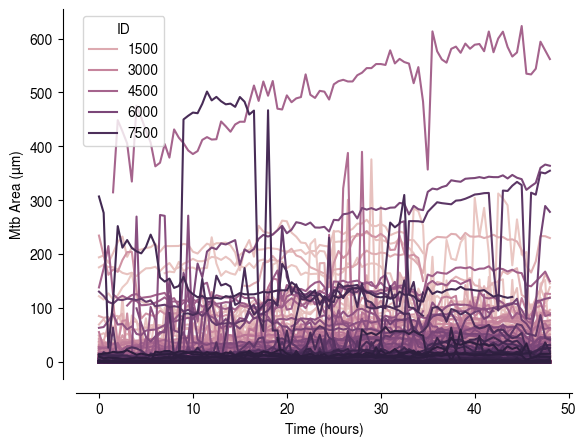

In [11]:
sns.lineplot(data=df, x='Time (hours)', y = 'Mtb Area (µm)', hue='ID')
sns.despine(offset=10)


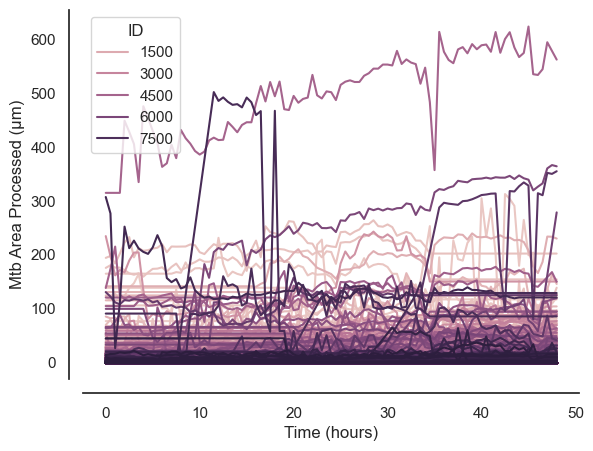

In [12]:
# ---- plot
sns.set_theme(style="white")
ax = sns.lineplot(
    data=df.dropna(subset=["Time (hours)", "Mtb Area Processed (µm)"]), 
    x="Time (hours)", y="Mtb Area Processed (µm)",
    hue="ID",
)
sns.despine(offset=10)


### Fit LOWESS growth models to Mtb growth

In [13]:
frac = 0.25
default_window = 10
control_window = 5
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score

# ensure a clean, unique, integer index
df = df.reset_index(drop=True)
assert df.index.is_unique

df = df.copy()
df["Time Model (hours)"] = np.nan
df["Mtb Area Model (µm)"] = np.nan
df["r2"] = np.nan

for ID in tqdm(df["ID"].unique(), desc="Fitting LOWESS"):
    sc_df = df[df["ID"] == ID]
    window = control_window if (isinstance(ID, str) and "PS0000" in ID) else default_window

    # 1) sort by time so LOWESS x is monotonic and aligns on write-back
    sc = sc_df.sort_values("Time (hours)").copy()
    time = sc["Time (hours)"].to_numpy(dtype=float)
    pop  = sc["Mtb Area Processed (µm)"].to_numpy(dtype=float)

    if len(time) < 10:
        continue

    # 2) LOWESS returns (x_sorted, y_smoothed) at the same x positions
    model = sm.nonparametric.lowess(endog=pop, exog=time, frac=frac, return_sorted=True)
    time_model = model[:, 0]                      # <-- no shift
    population_model = np.clip(model[:, 1], 0, None)

    # 3) write back to the *sorted* rows so positions match
    df.loc[sc.index, "Time Model (hours)"] = time_model
    df.loc[sc.index, "Mtb Area Model (µm)"] = population_model

    # 4) r² on aligned arrays (same length, sorted)
    df.loc[sc.index, "r2"] = r2_score(pop, model[:, 1])

Fitting LOWESS:   0%|          | 0/1344 [00:00<?, ?it/s]

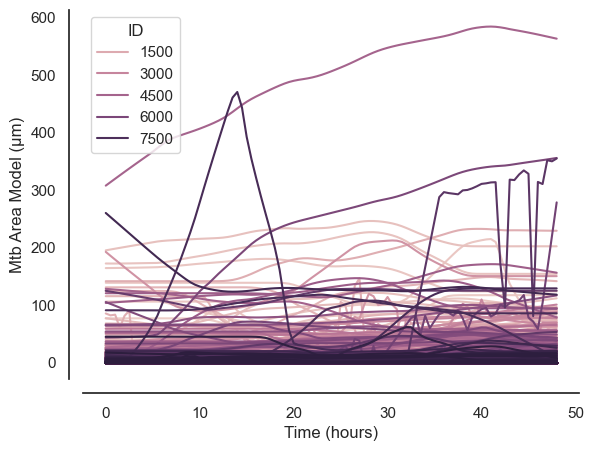

In [68]:
sns.lineplot(data=df.dropna(subset=["Time (hours)", "Mtb Area Model (µm)"]), 
            x='Time (hours)', y = 'Mtb Area Model (µm)', hue='ID')
sns.despine(offset=10)

### Compute doubling metrics from growth model

In [14]:
r2_threshold = 0.7
min_area = 1.92
df = df.copy()

# df["Doubling Amounts"] = None
# df["Doubling Times"] = None
results = []

for ID in tqdm(df["ID"].unique(), desc="Doubling Metrics"):
    sc_df = df[df["ID"] == ID].dropna(
        subset=[
            "Time Model (hours)",
            "Mtb Area Model (\u00b5m)",
            "Mtb Area Processed (\u00b5m)",
        ]
    )
    if sc_df.empty:
        continue

    r2 = sc_df["r2"].iloc[0]
    if r2 < r2_threshold:
        continue

    min_val = max(sc_df["Mtb Area Model (\u00b5m)"].min(), min_area)
    max_val = sc_df["Mtb Area Model (\u00b5m)"].max()
    if max_val <= min_val:
        continue

    N_series = []
    N_i = min_val
    while N_i <= max_val:
        N_series.append(N_i)
        N_i *= 2

    if len(N_series) < 2:
        continue

    times = sc_df["Time Model (hours)"]
    model_vals = sc_df["Mtb Area Model (\u00b5m)"]

    doubling_idx = [np.abs(model_vals - val).idxmin() for val in N_series]
    doubling_times = (
        times.loc[doubling_idx].diff().dropna().values.tolist()
    )

    results.append(
        {
            "ID": ID,
            "Doubling Amounts": N_series,
            "Doubling Times": doubling_times,
        }
    )

results_df = pd.DataFrame(results)
# Merge results back into df by ID
df = df.merge(results_df, on="ID", how="left")


Doubling Metrics:   0%|          | 0/1344 [00:00<?, ?it/s]

/tmp/ipykernel_212326/1937694198.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Doubling Times'].explode(), palette='mako')


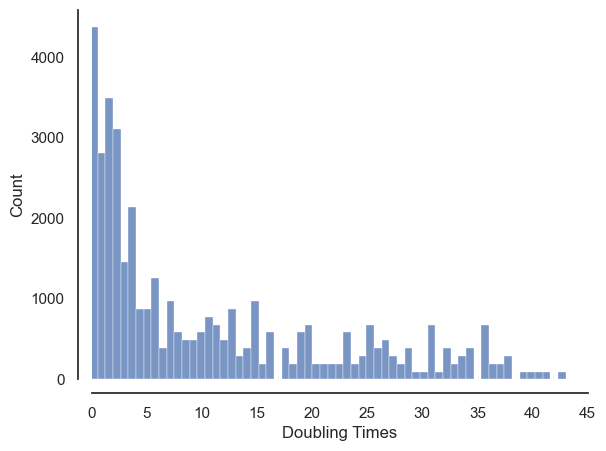

In [15]:
sns.histplot(df['Doubling Times'].explode(), palette='mako')
plt.xlim(0,45)
sns.despine(offset=10)

# Plot all dt with ID colour code

/tmp/ipykernel_212326/1894280801.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_212326/1894280801.py:24: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


Text(0.5, 1.0, 'Doubling times over full 25µm max projection')

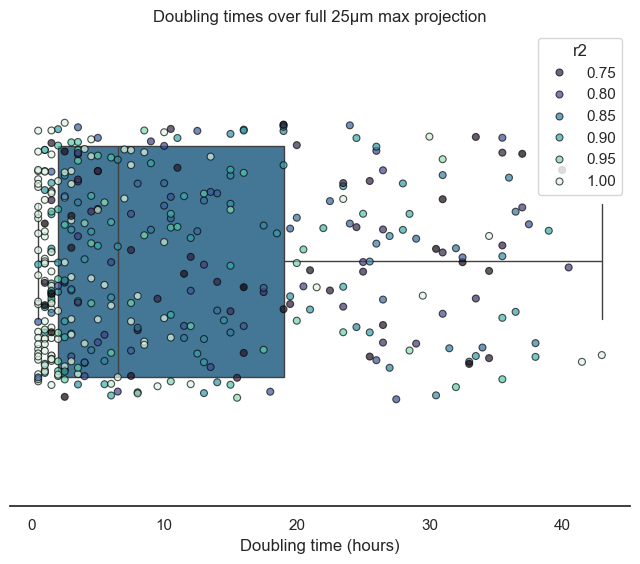

In [17]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode("Doubling Times")
)

subset_df = subset_df[
    # subset_df[id_key].isin(largest_IDs) &
    (subset_df["Doubling Times"] > 0) &
    (subset_df["r2"] >= 0.7)
].copy()

plt.figure(figsize=(8,6))
ax = sns.boxplot(
    data=subset_df,
    x="Doubling Times",
    whis=[0, 100],
    width=0.5,
    color=None,
    palette="mako"
)

# Overlay per-ID scatter, each ID with its own color + legend
sns.stripplot(
    data=subset_df,
    x="Doubling Times",
    hue="r2",              # categorical grouping
    palette="mako",           # or "tab10" for 10 distinct colors
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.3,
    dodge=False
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")

plt.title('Doubling times over full 25µm max projection')

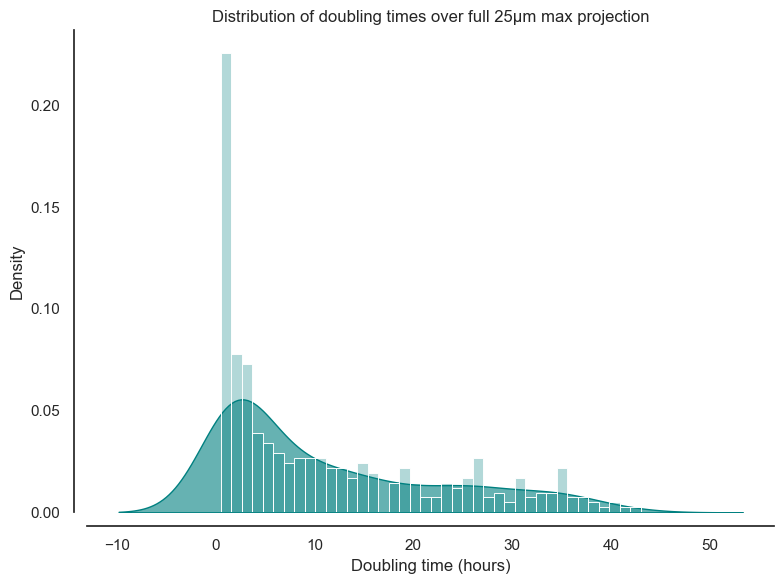

In [18]:
plt.figure(figsize=(8,6))

# Smooth KDE distribution
sns.kdeplot(
    data=subset_df,
    x="Doubling Times",
    fill=True,
    common_norm=False,
    alpha=0.6,
    color="teal"  # or use a palette if you want groups
)

# Optionally overlay a histogram
sns.histplot(
    data=subset_df,
    x="Doubling Times",
    bins=40,
    color="teal",
    alpha=0.3,
    stat="density"   # normalize so it overlays with KDE
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")
plt.title("Distribution of doubling times over full 25µm max projection")
plt.tight_layout()
plt.show()


### Load OG df

In [20]:
og_df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [21]:
og_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


In [22]:
subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

subset_og_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
405,0.0,46.797680,136.772588,660.776979,-68.386294,NaN,1.0,1.0,519.922607,876.779602,...,NaN,NaN,NaN,NaN,Growth,"[50.6, 101.2]",28.0,0.97,0,NaN
8714,11.0,34.036708,140.325993,479.262769,952.290318,NaN,1.0,1.0,682.521484,528.266724,...,NaN,NaN,NaN,NaN,Growth,"[44.1, 88.2]",32.0,0.95,22,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",29.0,0.91,0,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",33.0,0.91,0,NaN
22011,0.0,51.736691,109.038147,500.292664,-184.799433,NaN,1.0,1.0,140.723206,642.738159,...,NaN,NaN,NaN,NaN,Growth,"[65.7, 131.4]",38.5,0.97,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",25.0,0.98,3,NaN
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",33.0,0.98,3,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",17.0,0.96,4,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",15.0,0.96,4,NaN


/tmp/ipykernel_212326/1962237016.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_212326/1962237016.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_212326/1962237016.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


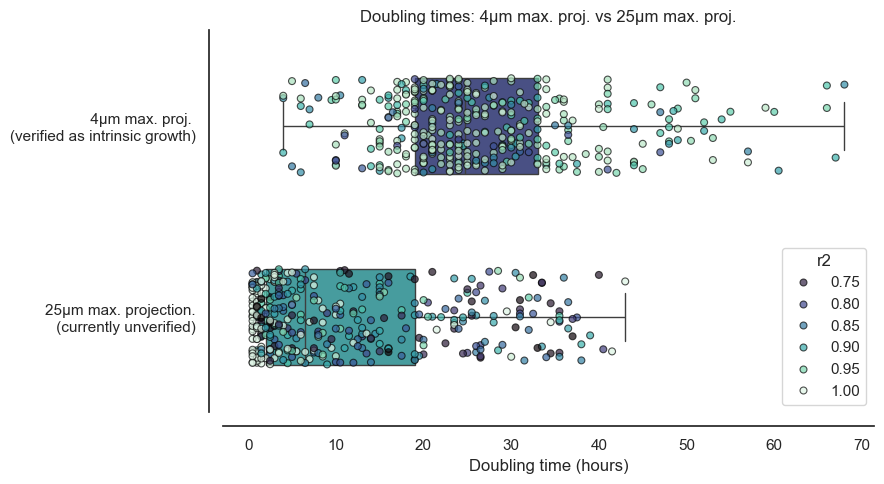

In [23]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.")
# ax.legend(title="r²", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()


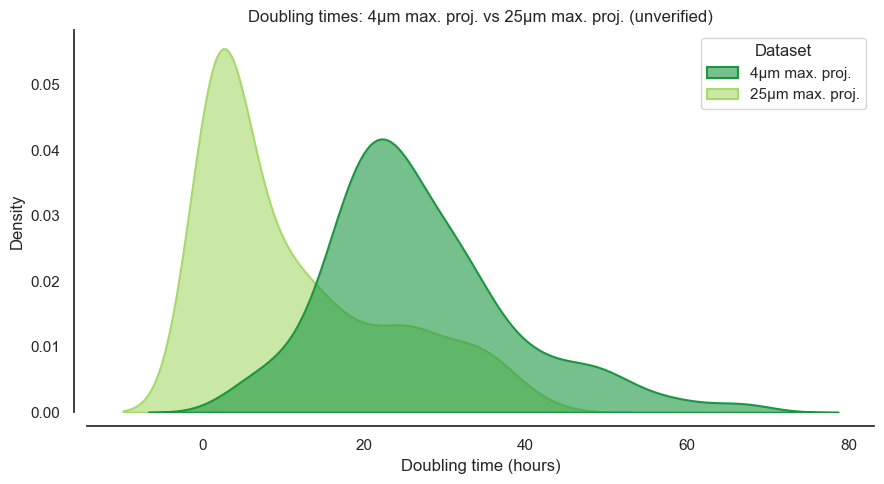

In [30]:
plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_212326/3447116030.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_212326/3447116030.py:30: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_212326/3447116030.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


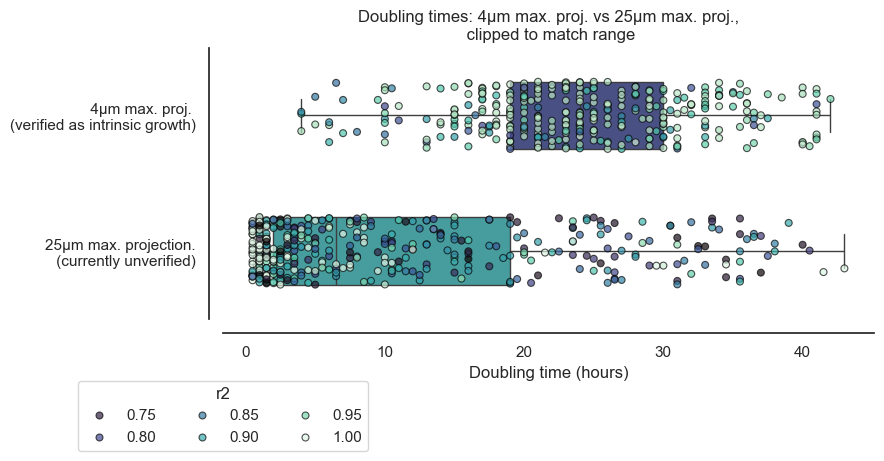

In [32]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='r2'
)
plt.tight_layout()


/tmp/ipykernel_212326/2198055433.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_212326/2198055433.py:47: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_212326/2198055433.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


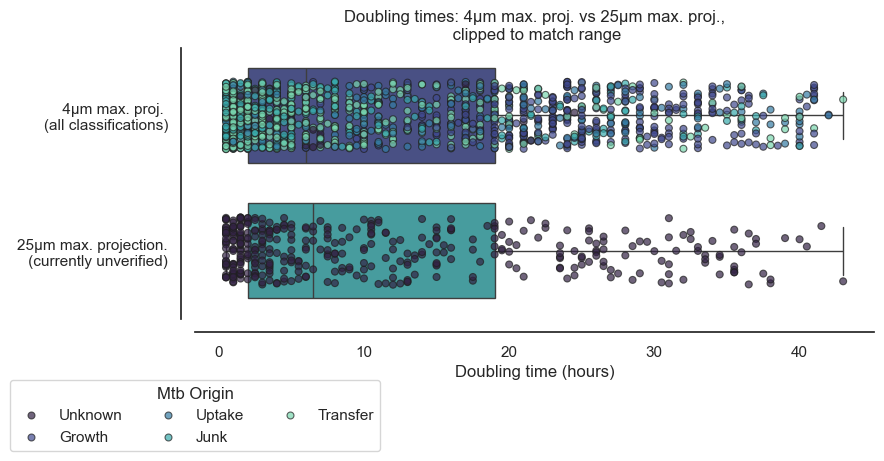

In [33]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
a['mtb_origin'] = 'Unknown'


subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        # & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.7,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='mtb_origin'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(all classifications)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='Mtb Origin'
)
plt.tight_layout()


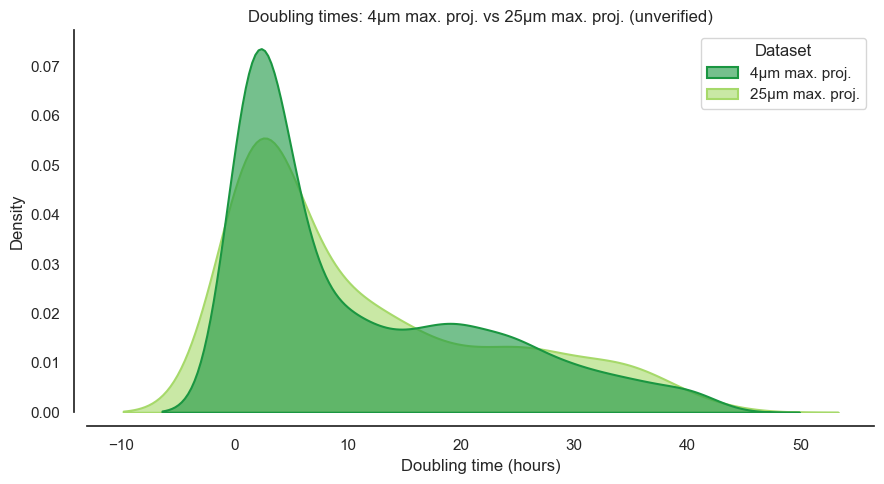

In [34]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
a['mtb_origin'] = 'Unknown'


subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        # & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_9885/3536982499.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_9885/3536982499.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_9885/3536982499.py:46: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_9885/3536982499.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


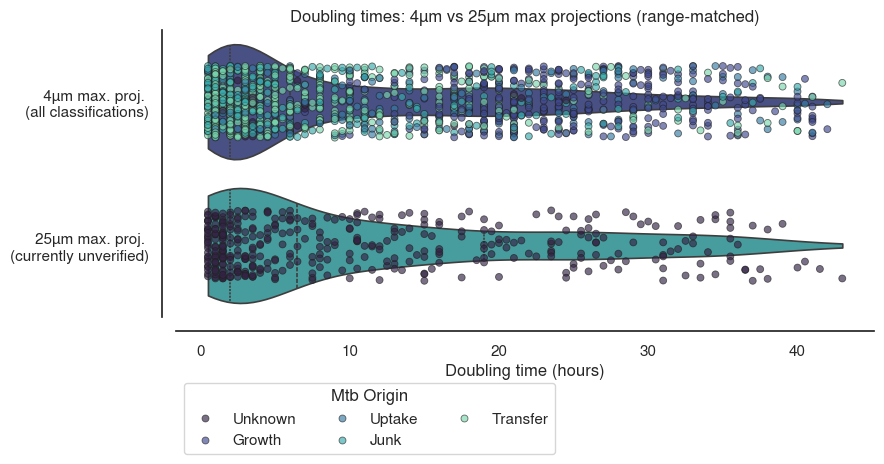

In [182]:
# Prepare datasets
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
a["mtb_origin"] = "Unknown"

subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

b = subset_og_df.copy().assign(Dataset="4µm max. proj.")
b = b[b["Doubling Times"] <= a["Doubling Times"].max()]

combo = pd.concat([a, b], ignore_index=True)
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

# Plot — horizontal violins + jittered points
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue=None,
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1.2,
    palette="mako"
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="mtb_origin",
    palette='mako',
    alpha=0.65,
    edgecolor="gray",
    linewidth=0.6,
    jitter=0.25,
    dodge=False
)

# Legend for mtb_origin only
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(
        handles=handles[-combo["mtb_origin"].nunique():],
        labels=labels[-combo["mtb_origin"].nunique():],
        title="Mtb Origin",
        bbox_to_anchor=(0.0, -0.2),
        loc="upper left",
        ncol=3,
        frameon=True,
    )

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(all classifications)",
    "25µm max. proj. \n(currently unverified)"
])
ax.set_title("Doubling times: 4µm vs 25µm max projections (range-matched)")
plt.tight_layout()


# Manually check the doubling times

In [35]:
# Sort by doubling time
subset_df_sorted = subset_df.sort_values("Doubling Times")

# Extract IDs in sorted order (keep first occurrence only)
ordered_ids = subset_df_sorted.drop_duplicates("ID")["ID"].tolist()

# Iterate
for ID in ordered_ids:
    df_id = subset_df[subset_df["ID"] == ID]
    dt_val = subset_df_sorted.loc[subset_df_sorted["ID"] == ID, "Doubling Times"].iloc[0]
    print(f"ID {ID}, DT={dt_val}")


ID 1307, DT=0.5
ID 3077, DT=0.5
ID 254, DT=0.5
ID 2287, DT=0.5
ID 285, DT=0.5
ID 5215, DT=0.5
ID 2289, DT=0.5
ID 1928, DT=0.5
ID 2426, DT=0.5
ID 761, DT=0.5
ID 2763, DT=0.5
ID 2901, DT=0.5
ID 3494, DT=0.5
ID 4853, DT=0.5
ID 6461, DT=0.5
ID 3105, DT=0.5
ID 1806, DT=0.5
ID 1, DT=0.5
ID 7078, DT=0.5
ID 7697, DT=0.5
ID 1366, DT=0.5
ID 7230, DT=0.5
ID 1919, DT=0.5
ID 1312, DT=1.0
ID 2807, DT=1.0
ID 667, DT=1.0
ID 782, DT=1.0
ID 1456, DT=1.0
ID 1492, DT=1.0
ID 2112, DT=1.0
ID 1499, DT=1.0
ID 2032, DT=1.0
ID 3029, DT=1.0
ID 6216, DT=1.0
ID 6277, DT=1.0
ID 364, DT=1.0
ID 6470, DT=1.0
ID 7598, DT=1.0
ID 3547, DT=1.0
ID 8055, DT=1.0
ID 3190, DT=1.5
ID 2978, DT=1.5
ID 2609, DT=1.5
ID 2512, DT=1.5
ID 3961, DT=1.5
ID 4004, DT=1.5
ID 4091, DT=1.5
ID 4099, DT=1.5
ID 4351, DT=1.5
ID 5612, DT=1.5
ID 2166, DT=1.5
ID 1296, DT=1.5
ID 1135, DT=1.5
ID 5969, DT=2.0
ID 6014, DT=2.0
ID 3596, DT=2.0
ID 3591, DT=2.0
ID 8562, DT=2.0
ID 7380, DT=2.0
ID 3241, DT=2.5
ID 4824, DT=2.5
ID 573, DT=2.5
ID 4849, DT=2.5
ID

<Axes: ylabel='Mtb Area Model (µm)'>

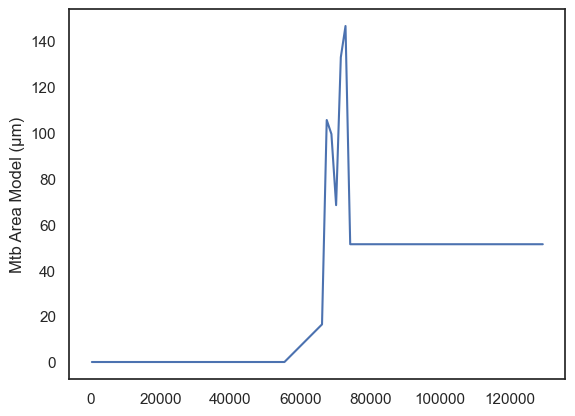

In [37]:
sns.lineplot(df[df['ID'] == 1307]['Mtb Area Model (µm)'])

In [45]:
max_proj_images = timed_compute(images.max(axis=2))

  0%|          | 0/97 [00:00<?, ?it/s]

In [46]:
max_proj_masks = timed_compute(masks[:,12,...])

  0%|          | 0/97 [00:00<?, ?it/s]

In [ ]:
viewer = napari.Viewer(title='inspecting whole fov dts')
viewer.add_image(max_proj_images, channel_axis=1)
viewer.add_labels(max_proj_masks)


Cannot move to target thread (0x64fe9f055970)

Cannot move to target thread (0x64fe9f055970)


Available platform plugins are: xcb, eglfs, minimal, minimalegl, offscreen, vnc, webgl.



In [ ]:
napari_tracks = tracks[tracks['z']==12][['ID', 't', 'y', 'x']].dropna().values

In [ ]:
viewer.add_tracks(napari_tracks)

### Functions

In [40]:
def highlight_cell(
    cell_ID,
    viewer,
    tracks,
    *,
    scale_factor: float = 1.0,
    napari_scale=None,
    size: int = 300,
    opacity: float = 1.0,
    symbol: str = "o",
    reset_position: bool = True,
):
    """
    Highlight a cell's trajectory in napari.

    Parameters
    ----------
    cell_ID : int
        Cell ID to highlight.
    viewer : napari.viewer.Viewer
        The napari viewer instance.
    tracks : list[Tracklet] | np.ndarray | pd.DataFrame
        Either:
          • a list of Tracklet objects with attrs (ID, t, y, x), or
          • an array/DataFrame with columns ordered as ID T(Z)YX.
    scale_factor : float
        Factor to multiply Y/X coordinates.
    napari_scale : list[float] | None
        Scale metadata for napari.
    size, opacity, symbol, reset_position
        Visual options.

    Returns
    -------
    napari.layers.Points
    """

    import numpy as np
    import pandas as pd

    # --- Case 1: Tracklet objects ---
    if isinstance(tracks, (list, tuple)) and tracks and hasattr(tracks[0], "ID"):
        tr = next(t for t in tracks if t.ID == cell_ID)
        points = np.column_stack([
            np.asarray(tr.t, dtype=float),
            np.asarray(tr.y, dtype=float) * scale_factor,
            np.asarray(tr.x, dtype=float) * scale_factor,
        ])
        has_z = False

    # --- Case 2: Array/DataFrame, schema = ID T(Z)YX ---
    else:
        if isinstance(tracks, pd.DataFrame):
            arr = tracks.to_numpy(dtype=float)
            cols = list(tracks.columns)
            has_z = "z" in cols
        else:
            arr = np.asarray(tracks, dtype=float)
            has_z = arr.shape[1] == 5

        # Filter rows by ID
        arr = arr[arr[:, 0] == float(cell_ID)]

        # Drop NaN rows
        arr = arr[~np.isnan(arr).any(axis=1)]
        if arr.size == 0:
            raise ValueError(f"No valid samples for cell {cell_ID}.")

        if has_z:
            t, z, y, x = arr[:, 1], arr[:, 2], arr[:, 3] * scale_factor, arr[:, 4] * scale_factor
            points = np.column_stack([t, z, y, x])
        else:
            t, y, x = arr[:, 1], arr[:, 2] * scale_factor, arr[:, 3] * scale_factor
            points = np.column_stack([t, y, x])

    # --- Add to napari ---
    layer = viewer.add_points(
        points,
        size=size,
        symbol=symbol,
        face_color="transparent",
        edge_color="white",
        edge_width=0.1,
        name=f"cell {cell_ID}",
        opacity=opacity,
        scale=napari_scale,
    )

    if reset_position:
        step = tuple(int(round(v)) for v in points[0])
        viewer.dims.current_step = step

    return layer

In [41]:
def mark_transfer(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Transfer'
    print(f"ID {ID} marked as 'Transfer'.")

def mark_uptake(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Uptake'
    print(f"ID {ID} marked as 'Uptake'.")

def mark_junk(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Junk'
    print(f"ID {ID} marked as 'Junk'.")

def mark_growth(viewer):
    df.loc[df['ID'] == ID, 'mtb_origin'] = 'Growth'
    print(f"ID {ID} marked as 'Growth'.")

def save_df(viewer):
    df.to_pickle('/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')
    print('DataFrame saved out')


In [44]:
from macrohet import visualise

colours = visualise.colours.expanded_piyg

import tempfile

import imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.transform
from sklearn.metrics import r2_score


def plot(ID, df, save = False, napari = False):
    # Get single-cell trajectory in df format
    sc_df = df[df['ID'] == ID]
    # Drop NaN values specifically from the required columns
    sc_df = sc_df.dropna(subset=['Time Model (hours)', 'Mtb Area Model (µm)', 'Mtb Area Processed (µm)'])
    # Ensure there is temporal order
    sc_df = sc_df.sort_values(by='Time Model (hours)')
    
    # Extract Strain, Compound, and Concentration for the title
    strain, compound, concentration = 'WT', 'Ctrl', 'EC0' #sc_df[['Strain', 'Compound', 'Concentration']].iloc[0].values
    
    # Calculate the R2 value and skip plotting if R2 < 0.7
    r2 = round(r2_score(sc_df['Mtb Area Processed (µm)'], sc_df['Mtb Area Model (µm)']), 2)
    df.loc[df['ID'] == ID, 'r2'] = r2
    if r2 < 0.7:
        # ill_fitting_curves[ID] = r2
        # df.loc[df['ID'] == ID, 'Doubling Amounts'] = None
        # df.loc[df['ID'] == ID, 'Doubling Times'] = None
        print(f'Nee fitting ({r2})')
        # return
    
    # Find the temporal order of the minimum and maximum
    min_value = max(sc_df['Mtb Area Model (µm)'].round(1).min(), 1.92) # has to be above the minimum threshold
    max_value = sc_df['Mtb Area Model (µm)'].round(1).max()
    
    # perform a check on the data
    if max_value <= min_value:
        #non_doubling_curves.append(ID)
        print(f'No population doubling for ID {ID}')
    
    # Find the time indices of the minimum and maximum
    min_index = sc_df['Mtb Area Model (µm)'].round(1).idxmin()
    max_index = sc_df['Mtb Area Model (µm)'].round(1).idxmax()
    
    # Check if maximum occurs before minimum
    if max_index > min_index:
        growth = True
        # Minimum occurs before the maximum (indicating growth)
        # Start from the minimum and double
        N_i = min_value
        N_series = []
        
        # Generate the doubling series
        while N_i <= max_value:
            N_series.append(N_i)
            N_i *= 2
        
    else:
        growth = False
        # non_doubling_curves.append(ID)
        print(f'No obvious growth for ID {ID}')

        # Start from the maximum and halve
        N_i = max_value
        N_series = []
        
        # Generate the halving series
        while N_i >= min_value:
            N_series.append(N_i)
            N_i /= 2
    
    # Check if there are no valid doubling points
    if len(N_series) < 2:
        #non_doubling_curves.append(ID)
        print(f'No population doubling for ID {ID}')
        # df.loc[df['ID'] == ID, 'Doubling Amounts'] = None
        # df.loc[df['ID'] == ID, 'Doubling Times'] = None
        # return
        
    # Find the indices and corresponding times for each doubling point
    doubling_time_indices = np.clip(np.searchsorted(sc_df['Mtb Area Model (µm)'], N_series), 0, len(sc_df) - 1)
    doubling_time_points = sc_df['Time Model (hours)'].iloc[doubling_time_indices]
    doubling_times = doubling_time_points.diff().dropna().values.tolist()

    # Plot the experimental data and the fitted model
    plt.figure(figsize=(8, 6))
    plt.plot(sc_df['Time Model (hours)'], sc_df['Mtb Area Model (µm)'], label='Lowess Growth Model', color=colours[-2])
    plt.scatter(sc_df['Time Model (hours)'], sc_df['Mtb Area Processed (µm)'], label='Processed Data', color=colours[0], s=5)
    
    # Annotate doubling times and draw faint lines
    for i, (time, population) in enumerate(zip(doubling_time_points, N_series)):
        time = abs(time)
        population = abs(population)
        color_index = i % len(expanded_piyg)  # This ensures the color index wraps around
        # Draw faint vertical lines at doubling time points
        plt.axvline(x=time, color=expanded_piyg[color_index], linestyle='--', linewidth=1, alpha=0.5)
        plt.axhline(y=population, color=expanded_piyg[color_index], linestyle='--', linewidth=1, alpha=0.5)
        
        # Place a text label indicating the doubling time
        if i > 0:  # Start labeling from the second point
            previous_time = doubling_time_points.iloc[i-1]
            
            # Midpoint between the two lines
            label_x_pos = time  # Correct the label position
            # Adjust y-position to place the label just above the horizontal line
            label_y_pos = population + (population * 0.01)  # Slightly above the horizontal line
    
            # Calculate the gap between the lines and scale the font size
            gap = time - previous_time
            scaled_fontsize = max(8, min(12, gap))  # Scale font size within a reasonable range (e.g., 8 to 12)
            
            # Draw the horizontal doubling time label
            plt.text(label_x_pos, label_y_pos, f'{abs(doubling_times[i-1]):.2f}h', 
                     ha='right', va='bottom', alpha=0.5, fontsize=scaled_fontsize, color=expanded_piyg[0])
            
            # Draw vertical arrow showing the change in N_series (doubling amount)
            deltaMtb = population - N_series[i-1]
            
            # Midpoint for the vertical delta annotation
            text_y_pos = (population + N_series[i-1]) / 2  # Midway between current and previous population
            text_x_pos = (population + N_series[i-1]) / 2  # Midway between current and previous population
    
            # Midpoint between the two lines
            label_x_pos = time + 0.1  # Adjust x-position
            # Adjust y-position to place the label just above the horizontal line
            label_y_pos = population - (max_value * 0.01)
            
            # Place the vertical label using plt.text
            plt.text(label_x_pos, label_y_pos, f'Δ {abs(deltaMtb):.1f}µm²',
                     fontsize=scaled_fontsize, color=expanded_piyg[0], ha='left', va='top', rotation=270, alpha=0.5)
    
    # Add labels, legend, and titles
    plt.xlabel('Time (Hours)')
    plt.ylabel('Mtb Area µm$^{2}$')
    plt.legend()
        # Main title
    plt.suptitle('Single-Macrophage Intracellular Mtb Dynamics', 
                 weight='bold', fontsize=16)
    # Subtitle
    plt.title(f'Cell ID {ID} | Strain: {strain} | Compound: {compound} | Concentration: {concentration} | R² = {r2}', fontsize=12, pad=10)
    
    sns.despine(offset=10)
    plt.grid(False)
    
    if save:    
        plt.savefig(f'/mnt/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/sc_plot_examples/{ID}_dtmin{np.min(doubling_times)}_r2{r2}_graph.pdf', bbox_inches = 'tight', dpi = 314)
        # plt.close()
    if napari:
        # Save the current plot to a temporary file
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_plot:
            plt.savefig(tmp_plot.name, bbox_inches='tight', dpi=314)
            plot_image_path = tmp_plot.name
        plot_image = imageio.imread(plot_image_path)
        # Resize the plot image to have a width of 750 pixels, maintaining aspect ratio
        height, width = plot_image.shape[:2]
        new_width = 750
        scale_factor = new_width / width
        new_height = int(height * scale_factor)
        resized_plot_image = skimage.transform.resize(plot_image, (new_height, new_width), anti_aliasing=True)
        viewer.add_image(resized_plot_image, name=f'ID: {ID} Plot', )#colormap='gray')
        return doubling_times, N_series
    else:    
        plt.show()

### Execute

In [66]:

viewer.bind_key('t', mark_transfer)
viewer.bind_key('u', mark_uptake)
viewer.bind_key('j', mark_junk)
viewer.bind_key('g', mark_growth)
viewer.bind_key('s', save_df)

In [1]:
viewer

NameError: name 'viewer' is not defined

In [49]:
ID = 1307

/tmp/ipykernel_35872/2025097940.py:77: FutureWarning: Argument 'edge_width' is deprecated, please use 'border_width' instead. The argument 'edge_width' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  layer = viewer.add_points(
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari/utils/migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)


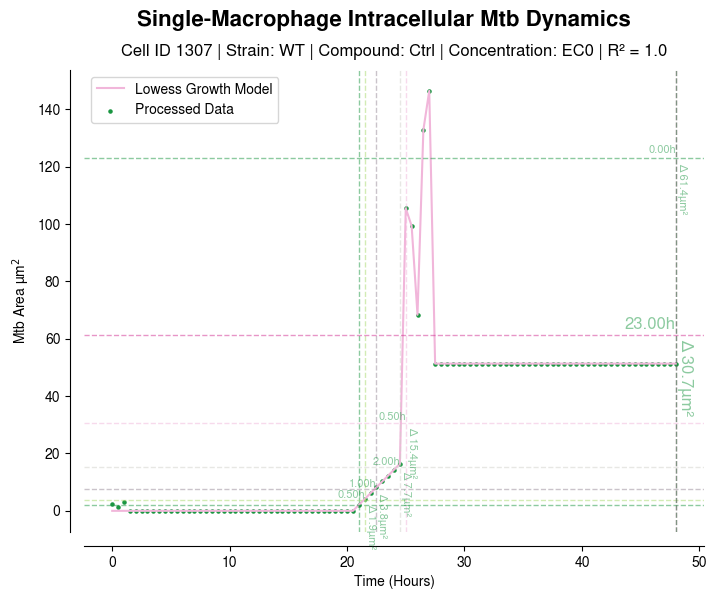

ID 1307 marked as 'Transfer'.


In [67]:
ID = 1307
highlight_cell(ID, viewer, napari_tracks)
plot(ID, df)

  0%|          | 0/218 [00:00<?, ?it/s]

Already classified ID: 1307 as Transfer


/tmp/ipykernel_35872/2025097940.py:77: FutureWarning: Argument 'edge_width' is deprecated, please use 'border_width' instead. The argument 'edge_width' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  layer = viewer.add_points(
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/napari/utils/migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)


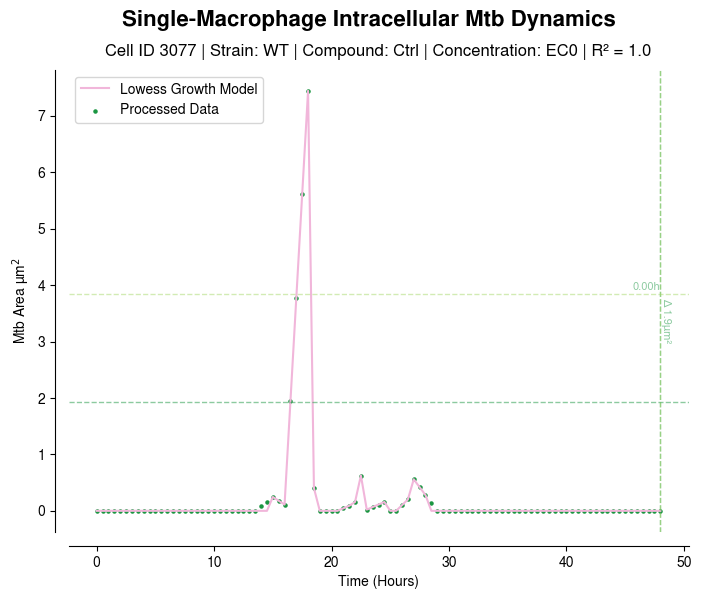

KeyboardInterrupt: 

In [ ]:
for ID in tqdm(ordered_ids):
    val = df[df['ID'] == ID]['mtb_origin'].iloc[0]
    if not pd.isna(val):
        print(f'Already classified ID: {ID} as {val}')
        continue
    
    viewer = napari.Viewer(title=f'inspecting dts for ID {ID}')
    viewer.add_image(max_proj_images, channel_axis=1)
    viewer.add_labels(max_proj_masks, visible=False)
    viewer.add_tracks(napari_tracks)
    highlight_cell(ID, viewer, napari_tracks)
    plot(ID, df)
    viewer.show(block=True)
    plt.close()

# It's clear that the 